# References & Deep Learning Sources

- How to Detect Outliers in Python: A Comprehensive Guide [Train in Data](https://www.blog.trainindata.com/detect-outliers-in-python/).


# NYC Trip Duration 


## Dataset Data Dictionary

| Feature | Description |
| :--- | :--- |
| `id` | A unique identifier for each trip. |
| `vendor_id` | A code indicating the provider associated with the trip record. |
| `pickup_datetime` | Date and time when the meter was engaged. |
| `dropoff_datetime` | Date and time when the meter was disengaged. |
| `passenger_count` | The number of passengers in the vehicle (driver entered value). |
| `pickup_longitude` | The longitude where the meter was engaged. |
| `pickup_latitude` | The latitude where the meter was engaged. |
| `dropoff_longitude` | The longitude where the meter was disengaged. |
| `dropoff_latitude` | The latitude where the meter was disengaged. |
| `store_and_fwd_flag` | This flag indicates whether the trip record was held in vehicle memory before sending to the vendor because the vehicle did not have a connection to the server (Y = store and forward; N = not a store and forward trip). |
| `trip_duration` | Duration of the trip in seconds (Target Variable). |

## Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/split_sample/train.csv')

In [3]:
df.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id1385950,1,2016-01-08 22:31:12,1,-73.990646,40.751068,-73.995789,40.728146,N,525
1,id1885523,2,2016-01-02 12:36:39,1,-73.982658,40.745071,-74.003258,40.732971,N,799
2,id0892204,2,2016-02-21 00:24:16,1,-73.999481,40.728580,-74.000252,40.718800,N,374
3,id2463973,2,2016-05-08 15:06:34,1,-73.977058,40.759850,-73.949989,40.776001,N,696
4,id1496105,2,2016-05-06 13:54:36,2,-73.977798,40.758221,-73.993080,40.743130,N,703


In [388]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  5000 non-null   object 
 1   vendor_id           5000 non-null   int64  
 2   pickup_datetime     5000 non-null   object 
 3   passenger_count     5000 non-null   int64  
 4   pickup_longitude    5000 non-null   float64
 5   pickup_latitude     5000 non-null   float64
 6   dropoff_longitude   5000 non-null   float64
 7   dropoff_latitude    5000 non-null   float64
 8   store_and_fwd_flag  5000 non-null   object 
 9   trip_duration       5000 non-null   int64  
dtypes: float64(4), int64(3), object(3)
memory usage: 390.8+ KB


In [389]:
# pickup_datetime - object
# store_and_fwd_flag - object

In [390]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
vendor_id,5000.0,1.520000,0.499650,1.000000,1.000000,2.000000,2.000000,2.000000
passenger_count,5000.0,1.654400,1.293250,1.000000,1.000000,1.000000,2.000000,6.000000
pickup_longitude,5000.0,-73.973659,0.057585,-74.177292,-73.991638,-73.981895,-73.967855,-70.851616
pickup_latitude,5000.0,40.751530,0.042378,40.619514,40.737639,40.754238,40.768205,43.017578
dropoff_longitude,5000.0,-73.972305,0.056861,-74.183403,-73.991266,-73.979771,-73.962240,-70.851616
dropoff_latitude,5000.0,40.752438,0.045901,40.575306,40.735735,40.754862,40.770319,43.017578
trip_duration,5000.0,969.608200,3616.929016,2.000000,392.000000,656.000000,1066.000000,86329.000000


- as we see there are a bige variance on Target Column we should handle it.

### Check Outlier

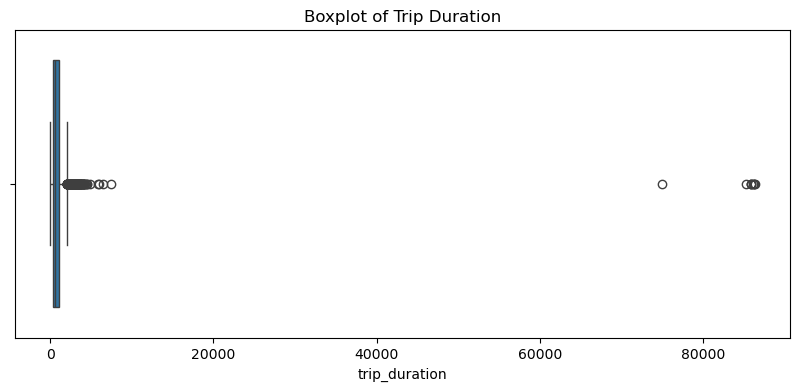

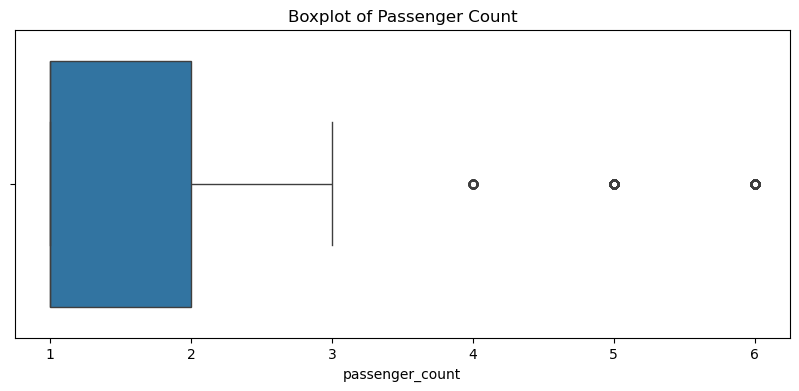

In [391]:
# 2. Boxplots
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['trip_duration'])
plt.title('Boxplot of Trip Duration')
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(x=df['passenger_count'])
plt.title('Boxplot of Passenger Count')
plt.show()

In [392]:
(df['trip_duration' ] > 60000).value_counts()

trip_duration
False    4991
True        9
Name: count, dtype: int64

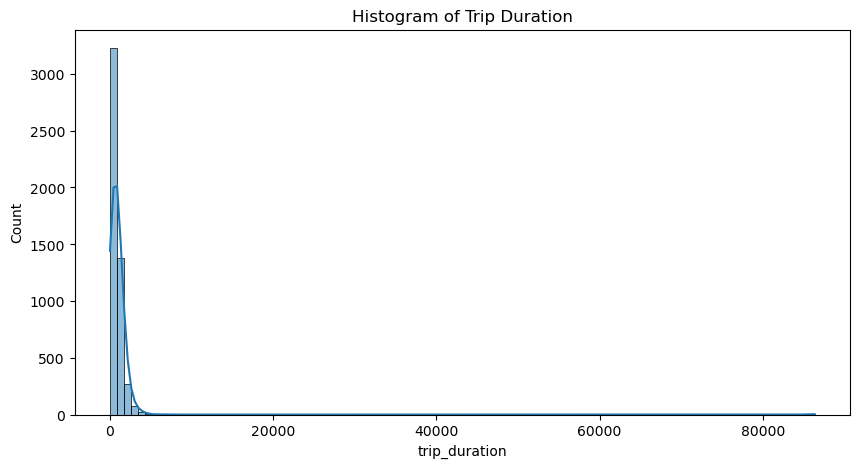

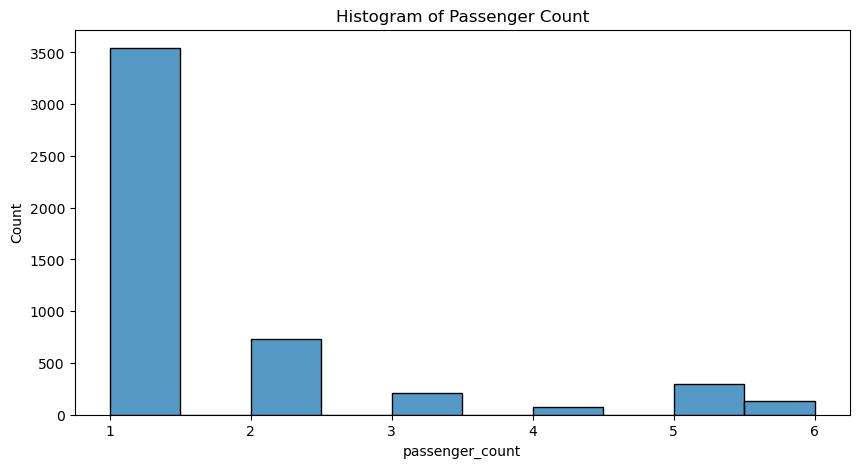

In [393]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='trip_duration', bins=100, kde=True)
plt.title('Histogram of Trip Duration')
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='passenger_count', bins=10, kde=False)
plt.title('Histogram of Passenger Count')
plt.show()

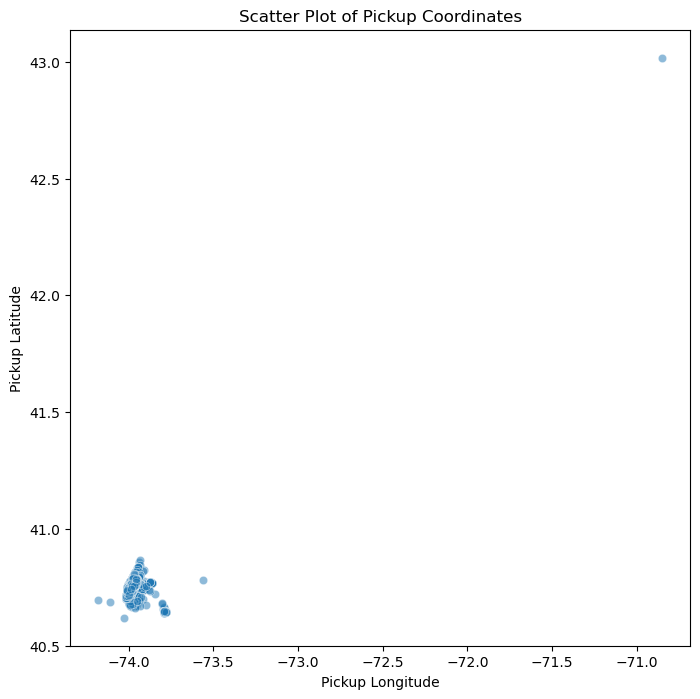

In [394]:
# 3. Scatter Plot
plt.figure(figsize=(8, 8))
sns.scatterplot(data=df, x='pickup_longitude', y='pickup_latitude', alpha=0.5)
plt.title('Scatter Plot of Pickup Coordinates')
plt.xlabel('Pickup Longitude')
plt.ylabel('Pickup Latitude')
plt.show()

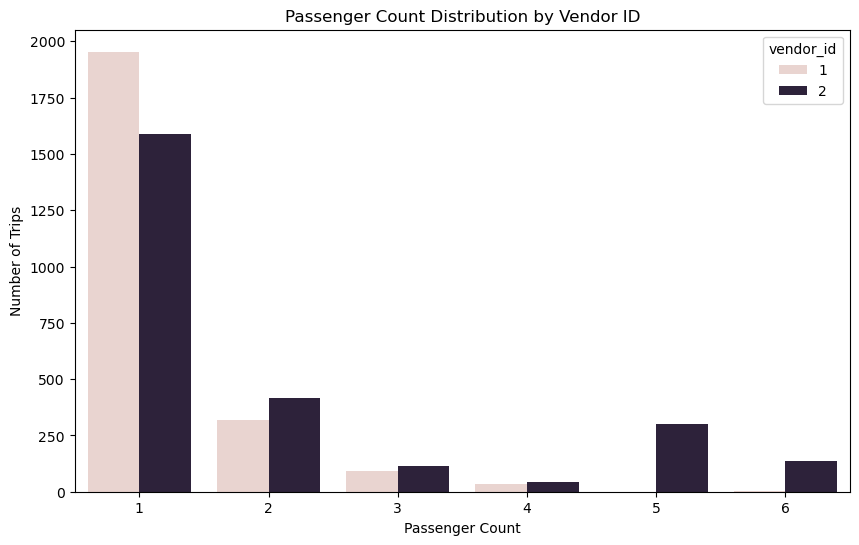

vendor_id                1          2
passenger_count                      
1                81.416667  61.076923
2                13.208333  16.038462
3                 3.833333   4.461538
4                 1.500000   1.653846
5                 0.000000  11.538462
6                 0.041667   5.230769


In [395]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='passenger_count', hue='vendor_id')
plt.title('Passenger Count Distribution by Vendor ID')
plt.xlabel('Passenger Count')
plt.ylabel('Number of Trips')
plt.show()

passenger_vendor_pct = pd.crosstab(
    df['passenger_count'], 
    df['vendor_id'], 
    normalize='columns'
) * 100

print(passenger_vendor_pct)

### Vendor ID & Passenger Count Analysis

* **Hypothesis:** Investigate if specific vendors tend to carry larger passenger groups, indicating different vehicle types (e.g., SUVs vs. Sedans).
* **Key Pattern Found:** * **Vendor 1:** Has exactly 0% trips with 5 passengers and nearly 0% with 6 passengers. This fleet likely consists strictly of standard 4-seater cars.
  * **Vendor 2:** Around 11.5% of trips have 5 passengers, and 5.2% have 6 passengers. This fleet clearly includes larger vehicles like SUVs or Minivans.
* **Conclusion:** Keeping passenger counts of 5 and 6 as valid data points—rather than removing or clipping them—is crucial. It preserves a real business pattern that helps the model differentiate between the two vendors' capacities.

In [396]:
# Filter data based on logical duration and NYC geographical boundaries
df_clean = df[
    (df['trip_duration'].between(60,7000))&
    (df['pickup_latitude'].between(40.5, 41.0)) &
    (df['pickup_longitude'].between(-74.25, -73.5))
].copy()

# Apply the correct log transformation to fix skewness
df_clean['trip_duration'] = np.log1p(df_clean['trip_duration'])

## EDA

In [397]:
def info(col):
    print("Min" , df_clean[col].min())
    print("Max" , df_clean[col].max())
    print("STD" , df_clean[col].std())
    print("Skewness" , df_clean[col].skew())
    print("Unique Values Counts" , df_clean[col].nunique())

    

In [398]:
def group_by(col,fun):
    group_fun = df_clean.groupby(col)['trip_duration'].agg(fun).reset_index()
    return group_fun

In [399]:
info('trip_duration')

Min 4.143134726391533
Max 8.777247096750544
STD 0.7212646228121452
Skewness -0.17198204678577622
Unique Values Counts 1769


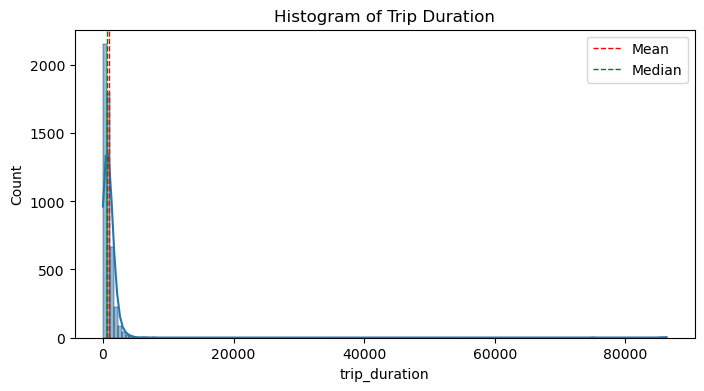

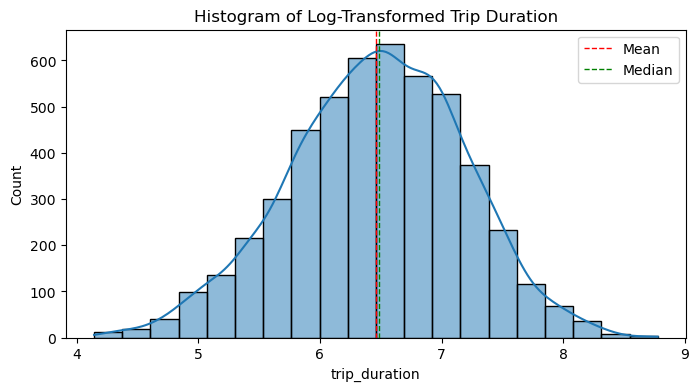

In [400]:
# before Log Transformation
plt.figure(figsize=(8,4))
sns.histplot(data=df, x='trip_duration', bins=150, kde=True)
plt.axvline(df['trip_duration'].mean(), color='r', linestyle='dashed', linewidth=1, label='Mean')
plt.axvline(df['trip_duration'].median(), color='g', linestyle='dashed', linewidth=1, label='Median')
plt.legend()
plt.title('Histogram of Trip Duration')
plt.show()

# after Log Transformation
plt.figure(figsize=(8,4))
sns.histplot(data=df_clean, x='trip_duration', bins=20, kde=True)
plt.axvline(df_clean['trip_duration'].mean(), color='r', linestyle='dashed', linewidth=1, label='Mean')
plt.axvline(df_clean['trip_duration'].median(), color='g', linestyle='dashed', linewidth=1, label='Median')
plt.legend()
plt.title('Histogram of Log-Transformed Trip Duration')
plt.show()




### Ttrip Duration Analysis

### Numerical Analysis

In [401]:
num = df_clean.select_dtypes(include=[np.number]).columns.tolist()
num

['vendor_id',
 'passenger_count',
 'pickup_longitude',
 'pickup_latitude',
 'dropoff_longitude',
 'dropoff_latitude',
 'trip_duration']

##### Vendor ID Analysis

In [402]:
info('vendor_id')

Min 1
Max 2
STD 0.4996145825265169
Skewness -0.08358268546520731
Unique Values Counts 2


In [403]:
sum_vendor_group = group_by('vendor_id' , 'count').sort_values(by='trip_duration' , ascending=False)

- there is no unbalance

In [404]:
group_by('vendor_id', 'mean').sort_values(by='trip_duration' , ascending=False)

,vendor_id,trip_duration
1,2,6.465091
0,1,6.462801


#### Pasenger Count Analysis

In [405]:
info('passenger_count')

Min 1
Max 6
STD 1.2950562261644574
Skewness 2.1266332561571093
Unique Values Counts 6


In [406]:
total_ride_duration_passenger = group_by('passenger_count' , 'count').sort_values(by='trip_duration' , ascending=False)

In [407]:
group_by('passenger_count' , 'mean').sort_values(by='trip_duration' , ascending=False)

,passenger_count,trip_duration
3,4,6.738457
1,2,6.503001
5,6,6.496203
2,3,6.460804
4,5,6.451916
0,1,6.449740


/tmp/ipykernel_3105/2613711674.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sum_vendor_group , x='vendor_id' , y = 'trip_duration' , palette='Reds' , ax= axes[0])
/tmp/ipykernel_3105/2613711674.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=total_ride_duration_passenger , x='passenger_count' , y = 'trip_duration' , palette='Reds' , ax= axes[1])


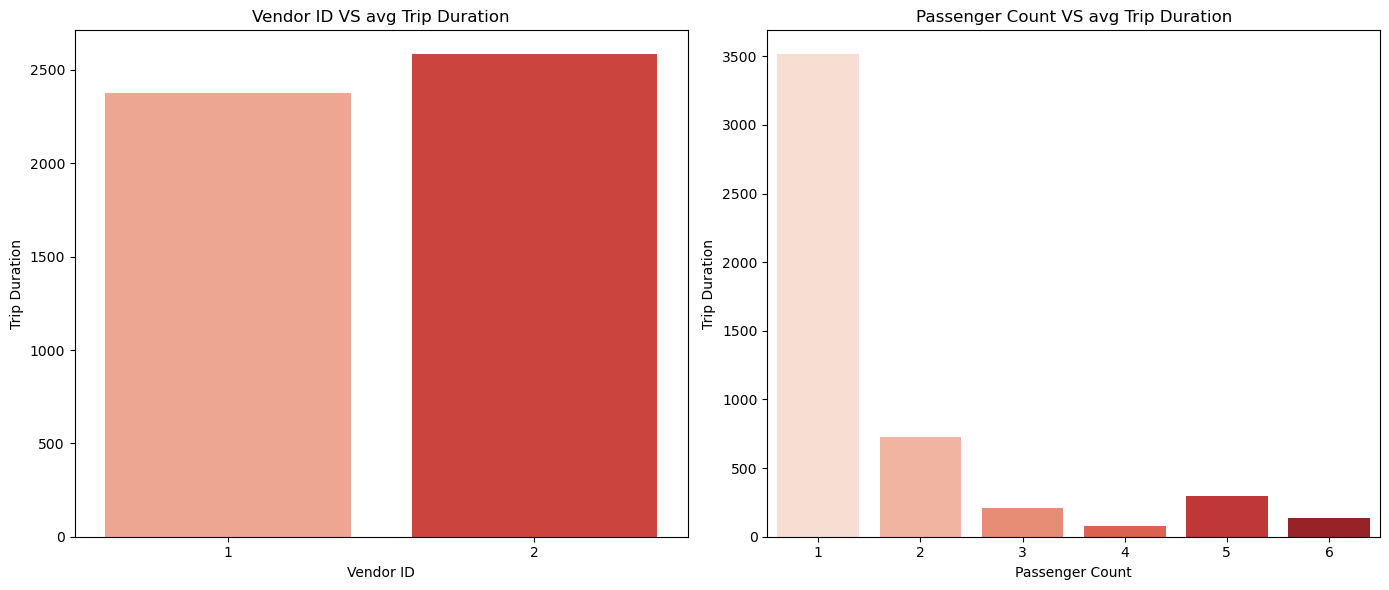

In [408]:
fig,axes = plt.subplots(1,2,figsize=(14,6))
sns.barplot(data=sum_vendor_group , x='vendor_id' , y = 'trip_duration' , palette='Reds' , ax= axes[0])
axes[0].set_title('Vendor ID VS avg Trip Duration')
axes[0].set_xlabel('Vendor ID')
axes[0].set_ylabel('Trip Duration')

sns.barplot(data=total_ride_duration_passenger , x='passenger_count' , y = 'trip_duration' , palette='Reds' , ax= axes[1])
axes[1].set_title('Passenger Count VS avg Trip Duration')
axes[1].set_xlabel('Passenger Count')
axes[1].set_ylabel('Trip Duration')

plt.tight_layout()
plt.show(Warning)

/tmp/ipykernel_3105/2838630305.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sum_vendor_group, x='vendor_id', y='trip_duration', palette='Reds', ax=axes[0])
/tmp/ipykernel_3105/2838630305.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=total_ride_duration_passenger, x='passenger_count', y='trip_duration', palette='Reds', ax=axes[1])


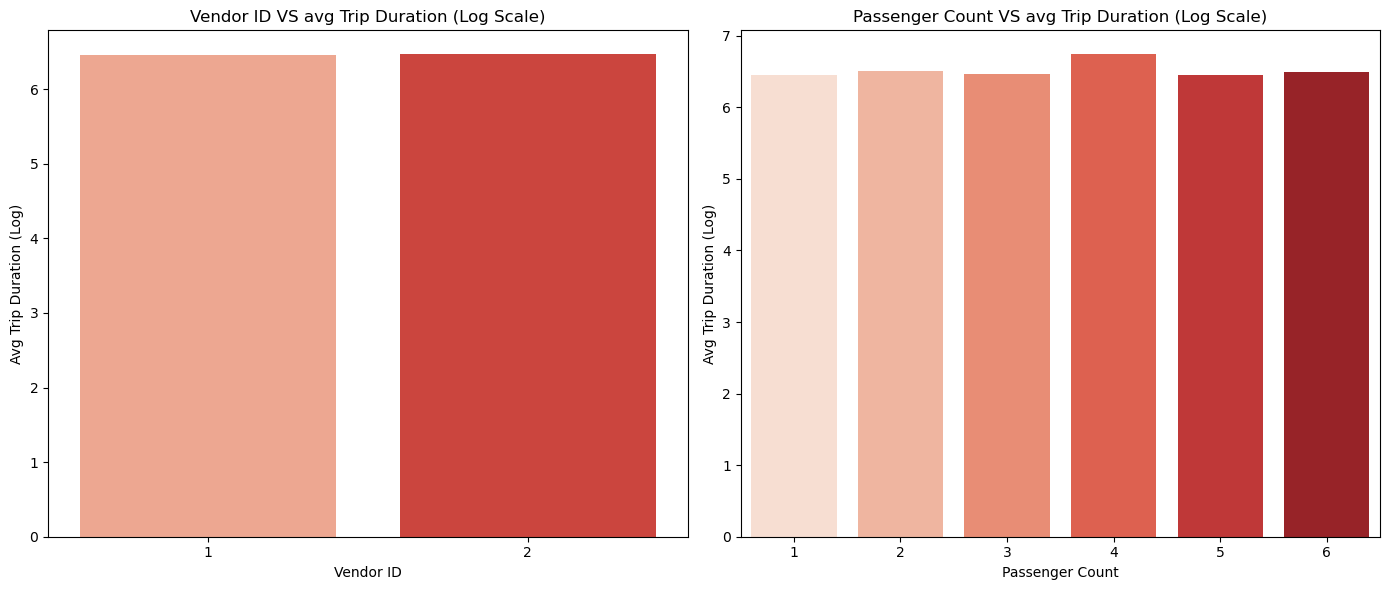

In [409]:
# 1. حساب المتوسطات من الداتا فريم النظيفة (df_clean) والتي تحتوي على الـ Log-Duration
sum_vendor_group = df_clean.groupby('vendor_id')['trip_duration'].mean().reset_index()
total_ride_duration_passenger = df_clean.groupby('passenger_count')['trip_duration'].mean().reset_index()

# 2. كود الرسم (نفس كودك بعد تعديل تسمية المحاور)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# الرسمة الأولى
sns.barplot(data=sum_vendor_group, x='vendor_id', y='trip_duration', palette='Reds', ax=axes[0])
axes[0].set_title('Vendor ID VS avg Trip Duration (Log Scale)')
axes[0].set_xlabel('Vendor ID')
axes[0].set_ylabel('Avg Trip Duration (Log)')

# الرسمة الثانية
sns.barplot(data=total_ride_duration_passenger, x='passenger_count', y='trip_duration', palette='Reds', ax=axes[1])
axes[1].set_title('Passenger Count VS avg Trip Duration (Log Scale)')
axes[1].set_xlabel('Passenger Count')
axes[1].set_ylabel('Avg Trip Duration (Log)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_3105/1828054570.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=group_data, x=col, y='trip_duration', palette='Blues_d', ax=axes[plot_idx])
/tmp/ipykernel_3105/1828054570.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=group_data, x=col, y='trip_duration', palette='Blues_d', ax=axes[plot_idx])
/tmp/ipykernel_3105/1828054570.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=group_data, x=col, y='trip_duration', palette='Blues_d', ax=axes[plot_idx])


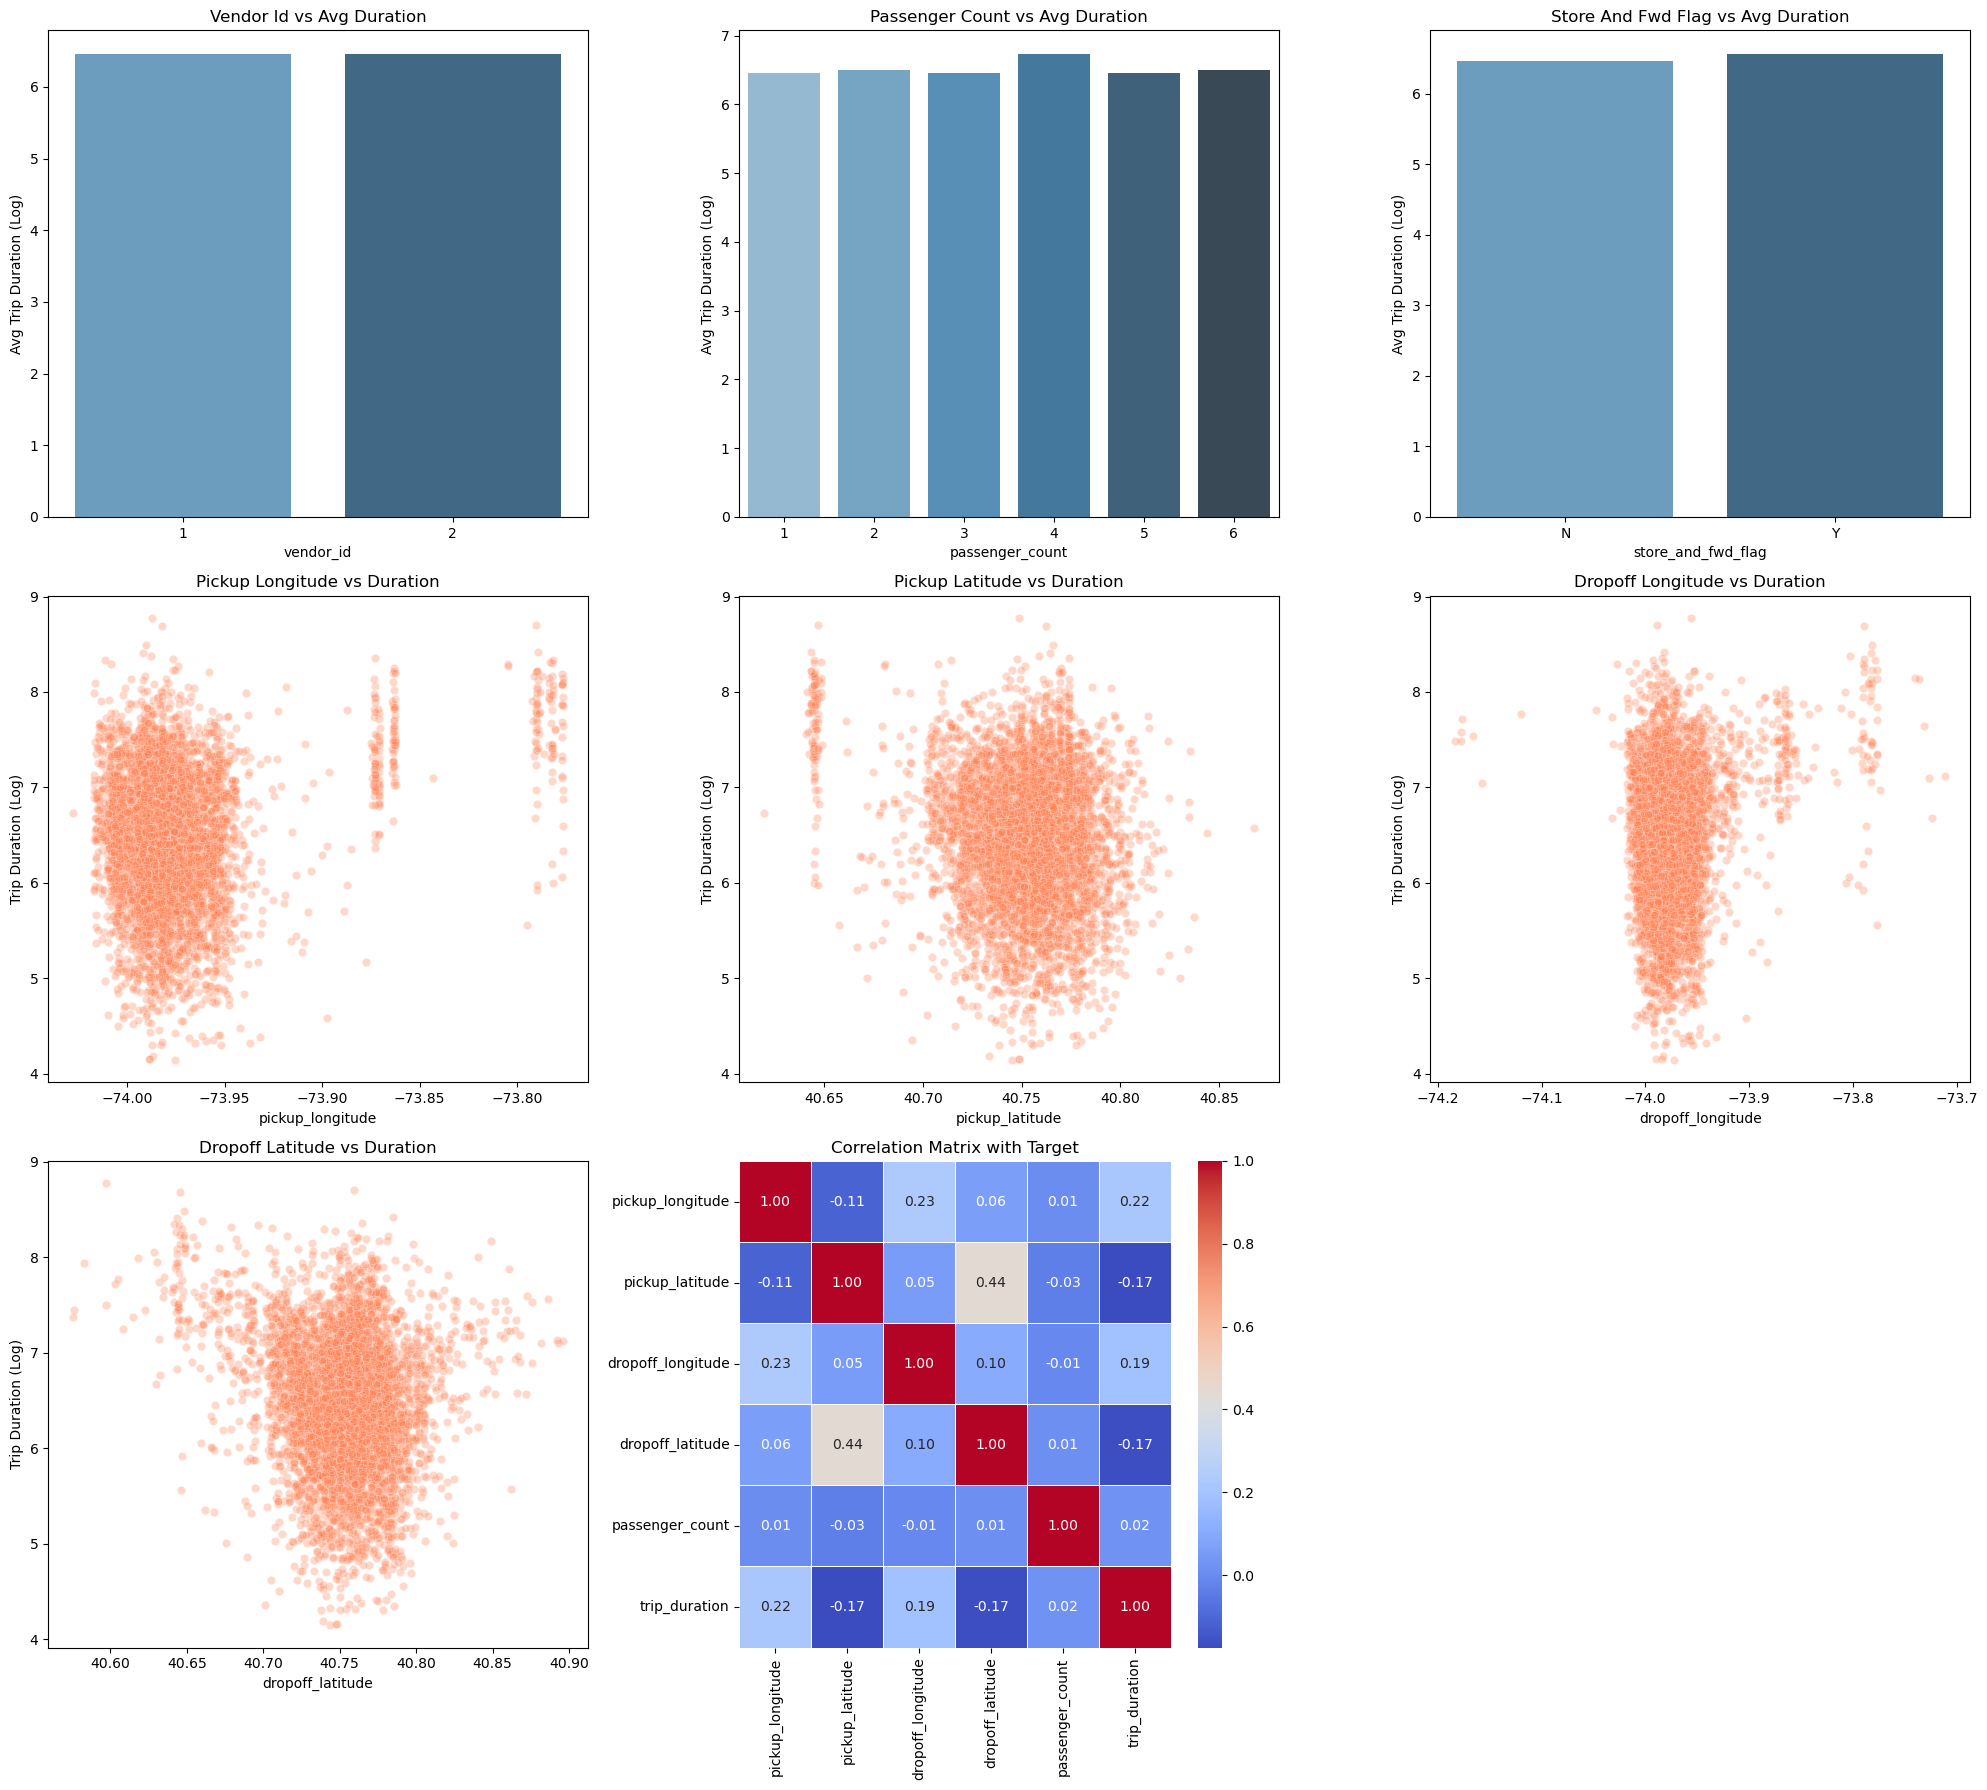

In [410]:
numerical_cols = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']
categorical_cols = ['vendor_id', 'passenger_count', 'store_and_fwd_flag']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 18))
axes = axes.flatten() 
plot_idx = 0

for col in categorical_cols:
    if col in df_clean.columns:
        group_data = df_clean.groupby(col)['trip_duration'].mean().reset_index()
        
        sns.barplot(data=group_data, x=col, y='trip_duration', palette='Blues_d', ax=axes[plot_idx])
        axes[plot_idx].set_title(col.replace('_', ' ').title() + ' vs Avg Duration')
        axes[plot_idx].set_ylabel('Avg Trip Duration (Log)')
        plot_idx += 1

df_sample = df_clean.sample(n=min(5000, len(df_clean)), random_state=42)

for col in numerical_cols:
    if col in df_clean.columns:
        sns.scatterplot(data=df_sample, x=col, y='trip_duration', alpha=0.3, color='coral', ax=axes[plot_idx])
        axes[plot_idx].set_title(col.replace('_', ' ').title() + ' vs Duration')
        axes[plot_idx].set_ylabel('Trip Duration (Log)')
        plot_idx += 1

all_num_cols = numerical_cols + ['passenger_count', 'trip_duration']
corr_matrix = df_clean[all_num_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=axes[plot_idx])
axes[plot_idx].set_title('Correlation Matrix with Target')
plot_idx += 1

for i in range(plot_idx, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

#### Longtitude & Latitude Analysis

In [411]:
num

['vendor_id',
 'passenger_count',
 'pickup_longitude',
 'pickup_latitude',
 'dropoff_longitude',
 'dropoff_latitude',
 'trip_duration']

In [412]:
feats = ['pickup_longitude','pickup_latitude','dropoff_longitude','dropoff_latitude']

In [413]:
for feat in feats:
    print('-'*10,feat , '-'*10 )
    info(feat)

---------- pickup_longitude ----------
Min -74.0279769897461
Max -73.77633666992188
STD 0.03612949107879505
Skewness 3.3974244825176068
Unique Values Counts 3713
---------- pickup_latitude ----------
Min 40.61951446533203
Max 40.86786651611328
STD 0.027534917909541063
Skewness -1.0471672202428806
Unique Values Counts 4349
---------- dropoff_longitude ----------
Min -74.18340301513672
Max -73.71074676513672
STD 0.03472415436920283
Skewness 2.643521525415212
Unique Values Counts 3835
---------- dropoff_latitude ----------
Min 40.5753059387207
Max 40.89621353149414
STD 0.03245120311053339
Skewness -0.5262291777385784
Unique Values Counts 4457


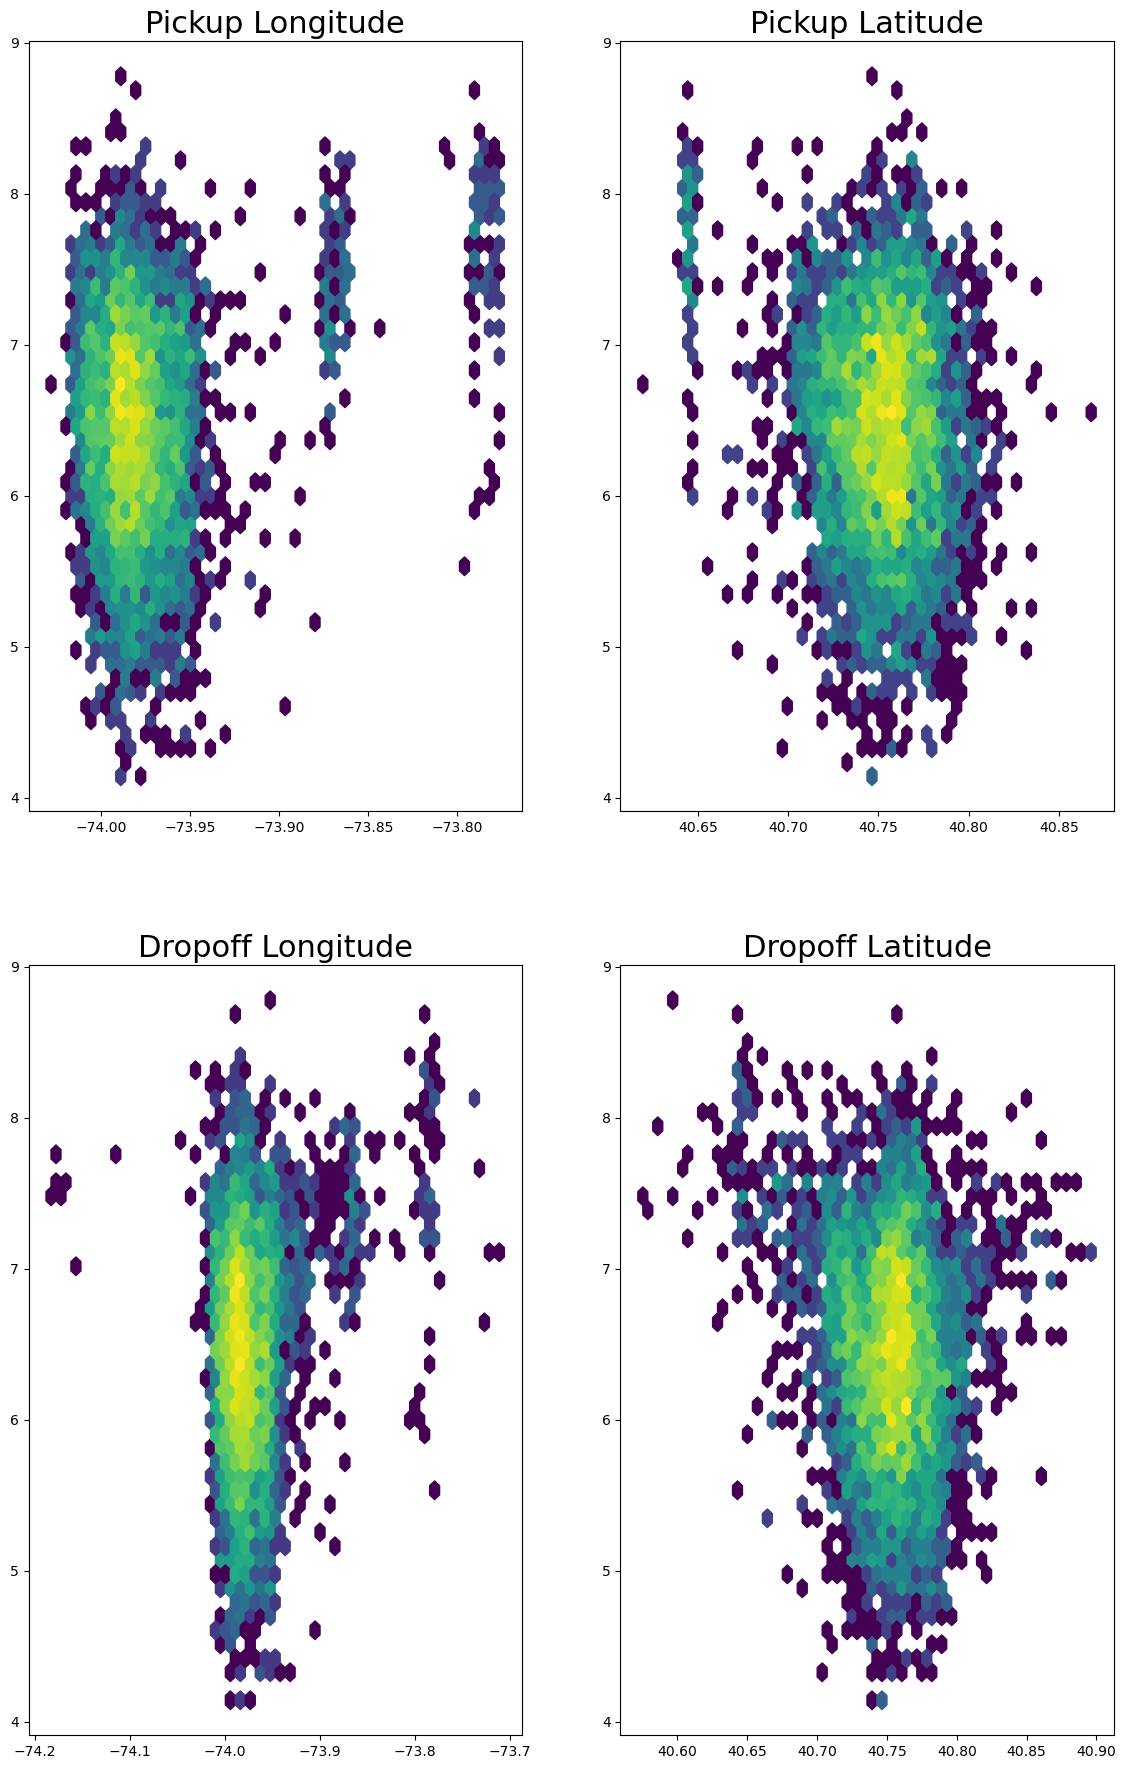

In [414]:
y =df_clean['trip_duration']
plt.figure(figsize=(14,22))
for i in range(4):
    ax = plt.subplot(2,2,i+1)
    hb = ax.hexbin(
        df_clean.loc[y.index,feats[i]],
        y,
        gridsize=45,
        bins='log',
        mincnt=1
    )
    ax.set_title(feats[i].replace('_' , ' ').title(),fontsize=22)

In [415]:
def calculate_distances(df):
    df['manhattan_dist'] = (df['dropoff_latitude'] - df['pickup_latitude']).abs() + \
                           (df['dropoff_longitude'] - df['pickup_longitude']).abs()
    
    df['euclidean_dist'] = np.sqrt(
        (df['dropoff_latitude'] - df['pickup_latitude'])**2 + 
        (df['dropoff_longitude'] - df['pickup_longitude'])**2
    )
    
    return df

df_clean = calculate_distances(df_clean)

geo_features = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'manhattan_dist', 'euclidean_dist', 'trip_duration']
print(df_clean[geo_features].corr()['trip_duration'].sort_values(ascending=False))

trip_duration        1.000000
euclidean_dist       0.646600
manhattan_dist       0.635679
pickup_longitude     0.219014
dropoff_longitude    0.191375
dropoff_latitude    -0.168982
pickup_latitude     -0.174650
Name: trip_duration, dtype: float64


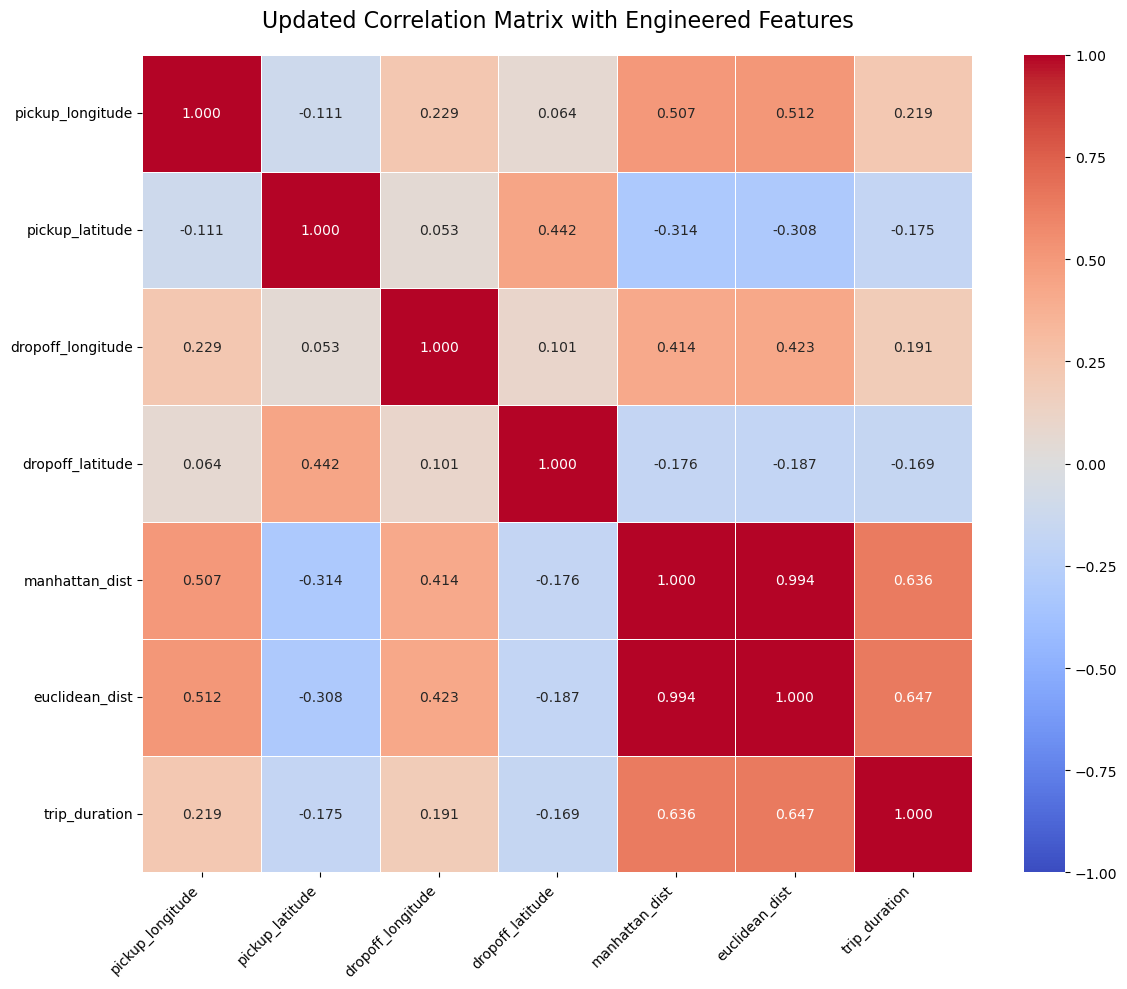

In [416]:
plt.figure(figsize=(12, 10))

new_features = [
    'trip_duration', 
    'manhattan_dist', 
    'euclidean_dist', 
    'passenger_count'
]

corr_matrix_updated = df_clean[geo_features].corr()

sns.heatmap(
    corr_matrix_updated, 
    annot=True,          
    cmap='coolwarm',     
    fmt=".3f",           
    linewidths=0.5,      
    vmin=-1, vmax=1     
)

plt.title('Updated Correlation Matrix with Engineered Features', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()

In [417]:
df_clean.columns

Index(['id', 'vendor_id', 'pickup_datetime', 'passenger_count',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration',
       'manhattan_dist', 'euclidean_dist'],
      dtype='object')

### Categorical Analysis

In [418]:
df_clean['store_and_fwd_flag'].value_counts()

store_and_fwd_flag
N    4923
Y      36
Name: count, dtype: int64

In [419]:
df_clean = df_clean.drop(columns=['store_and_fwd_flag'], errors='ignore')

#### Pickup Datetime

In [420]:
df_clean['pickup_datetime'].head()

0    2016-01-08 22:31:12
1    2016-01-02 12:36:39
2    2016-02-21 00:24:16
3    2016-05-08 15:06:34
4    2016-05-06 13:54:36
Name: pickup_datetime, dtype: object

In [421]:
df_clean['pickup_datetime']=pd.to_datetime(df_clean['pickup_datetime'])
df_clean['pickup_datetime'].head()

0   2016-01-08 22:31:12
1   2016-01-02 12:36:39
2   2016-02-21 00:24:16
3   2016-05-08 15:06:34
4   2016-05-06 13:54:36
Name: pickup_datetime, dtype: datetime64[ns]

In [ ]:
df_clean['hour'] = df_clean['pickup_datetime'].dt.hour
df_clean['day_of_week'] = df_clean['pickup_datetime'].dt.dayofweek
df_clean['month'] = df_clean['pickup_datetime'].dt.month
df_clean['is_weekend'] = df_clean['day_of_week'].isin([5, 6]).astype(int)
df_clean['hour_sin'] = np.sin(2 * np.pi * df_clean['hour'] / 24.0)
df_clean['hour_cos'] = np.cos(2 * np.pi * df_clean['hour'] / 24.0)
df_clean['day_sin'] = np.sin(2 * np.pi * df_clean['day_of_week'] / 7.0)
df_clean['day_cos'] = np.cos(2 * np.pi * df_clean['day_of_week'] / 7.0)
df_clean['month_sin'] = np.sin(2 * np.pi * df_clean['month'] / 12.0)
df_clean['month_cos'] = np.cos(2 * np.pi * df_clean['month'] / 12.0)
df_clean[['pickup_datetime', 'hour','hour_sin', 'hour_cos', 'day_of_week','day_sin','day_cos', 'is_weekend','month_sin','month_cos']].head()


,pickup_datetime,hour,hour_sin,hour_cos,day_of_week,day_sin,day_cos,is_weekend,month_sin,month_cos
0,2016-01-08 22:31:12,22,-5.000000e-01,0.866025,4,-0.433884,-0.900969,0,0.500000,0.866025
1,2016-01-02 12:36:39,12,1.224647e-16,-1.000000,5,-0.974928,-0.222521,1,0.500000,0.866025
2,2016-02-21 00:24:16,0,0.000000e+00,1.000000,6,-0.781831,0.623490,1,0.866025,0.500000
3,2016-05-08 15:06:34,15,-7.071068e-01,-0.707107,6,-0.781831,0.623490,1,0.500000,-0.866025
4,2016-05-06 13:54:36,13,-2.588190e-01,-0.965926,4,-0.433884,-0.900969,0,0.500000,-0.866025


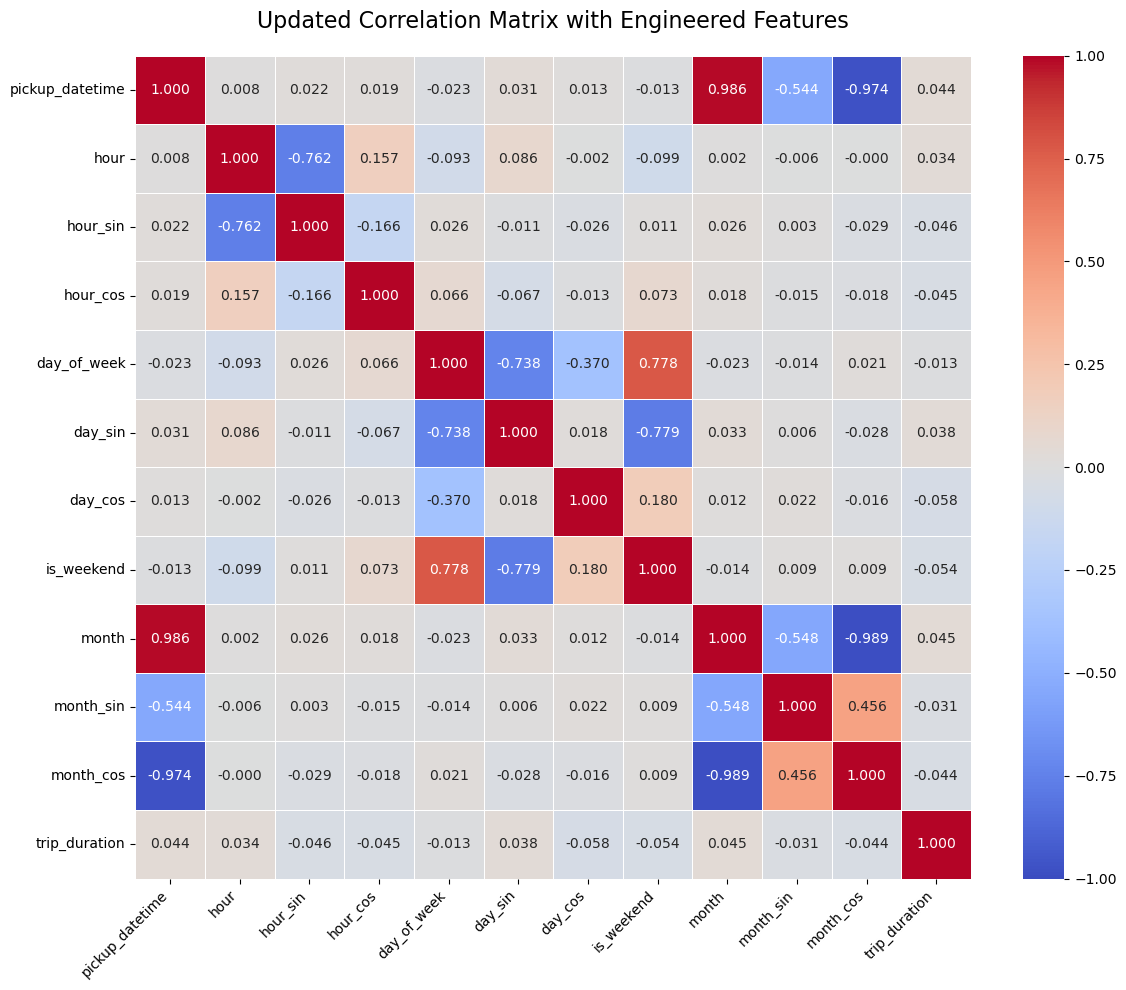

In [423]:
plt.figure(figsize=(12, 10))

new_features = ['pickup_datetime', 'hour','hour_sin', 'hour_cos', 'day_of_week','day_sin','day_cos', 'is_weekend','month','month_sin','month_cos','trip_duration']

corr_matrix_updated = df_clean[new_features].corr()

sns.heatmap(
    corr_matrix_updated, 
    annot=True,          
    cmap='coolwarm',     
    fmt=".3f",           
    linewidths=0.5,      
    vmin=-1, vmax=1     
)

plt.title('Updated Correlation Matrix with Engineered Features', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()

In [424]:
df_clean.columns

Index(['id', 'vendor_id', 'pickup_datetime', 'passenger_count',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'trip_duration', 'manhattan_dist', 'euclidean_dist',
       'hour', 'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos',
       'day_sin', 'day_cos', 'month_sin', 'month_cos'],
      dtype='object')

In [425]:
df_clean.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration,manhattan_dist,...,hour,day_of_week,month,is_weekend,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos
0,id1385950,1,2016-01-08 22:31:12,1,-73.990646,40.751068,-73.995789,40.728146,6.265301,0.028065,...,22,4,1,0,-5.000000e-01,0.866025,-0.433884,-0.900969,0.500000,0.866025
1,id1885523,2,2016-01-02 12:36:39,1,-73.982658,40.745071,-74.003258,40.732971,6.684612,0.032700,...,12,5,1,1,1.224647e-16,-1.000000,-0.974928,-0.222521,0.500000,0.866025
2,id0892204,2,2016-02-21 00:24:16,1,-73.999481,40.728580,-74.000252,40.718800,5.926926,0.010551,...,0,6,2,1,0.000000e+00,1.000000,-0.781831,0.623490,0.866025,0.500000
3,id2463973,2,2016-05-08 15:06:34,1,-73.977058,40.759850,-73.949989,40.776001,6.546785,0.043221,...,15,6,5,1,-7.071068e-01,-0.707107,-0.781831,0.623490,0.500000,-0.866025
4,id1496105,2,2016-05-06 13:54:36,2,-73.977798,40.758221,-73.993080,40.743130,6.556778,0.030373,...,13,4,5,0,-2.588190e-01,-0.965926,-0.433884,-0.900969,0.500000,-0.866025


In [426]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'winter'
    elif month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    else:
        return 'autumn'

df_clean['season'] = df_clean['month'].apply(get_season)


In [427]:
df_clean['season'].value_counts()

season
spring    2532
winter    1635
summer     792
Name: count, dtype: int64

In [428]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_clean['season'] = le.fit_transform(df_clean['season'])
df_clean['season']

0       2
1       2
2       2
3       0
4       0
       ..
4995    2
4996    0
4997    0
4998    1
4999    2
Name: season, Length: 4959, dtype: int64

In [429]:
df_clean.head(10)

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration,manhattan_dist,...,day_of_week,month,is_weekend,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,season
0,id1385950,1,2016-01-08 22:31:12,1,-73.990646,40.751068,-73.995789,40.728146,6.265301,0.028065,...,4,1,0,-5.000000e-01,8.660254e-01,-0.433884,-0.900969,0.500000,0.866025,2
1,id1885523,2,2016-01-02 12:36:39,1,-73.982658,40.745071,-74.003258,40.732971,6.684612,0.032700,...,5,1,1,1.224647e-16,-1.000000e+00,-0.974928,-0.222521,0.500000,0.866025,2
2,id0892204,2,2016-02-21 00:24:16,1,-73.999481,40.728580,-74.000252,40.718800,5.926926,0.010551,...,6,2,1,0.000000e+00,1.000000e+00,-0.781831,0.623490,0.866025,0.500000,2
3,id2463973,2,2016-05-08 15:06:34,1,-73.977058,40.759850,-73.949989,40.776001,6.546785,0.043221,...,6,5,1,-7.071068e-01,-7.071068e-01,-0.781831,0.623490,0.500000,-0.866025,0
4,id1496105,2,2016-05-06 13:54:36,2,-73.977798,40.758221,-73.993080,40.743130,6.556778,0.030373,...,4,5,0,-2.588190e-01,-9.659258e-01,-0.433884,-0.900969,0.500000,-0.866025,0
5,id2078915,2,2016-04-11 18:32:11,2,-73.996819,40.736294,-73.998276,40.740421,4.890349,0.005585,...,0,4,0,-1.000000e+00,-1.836970e-16,0.000000,1.000000,0.866025,-0.500000,0
6,id0108844,1,2016-01-04 19:12:50,1,-73.975967,40.758190,-73.961388,40.768890,5.981414,0.025280,...,0,1,0,-9.659258e-01,2.588190e-01,0.000000,1.000000,0.500000,0.866025,2
7,id3367964,2,2016-02-10 22:45:56,1,-73.980026,40.784012,-73.982224,40.774849,5.488938,0.011360,...,2,2,0,-5.000000e-01,8.660254e-01,0.974928,-0.222521,0.866025,0.500000,2
8,id0289251,2,2016-02-27 22:21:34,2,-74.005844,40.736256,-73.994995,40.750027,6.311735,0.024620,...,5,2,1,-5.000000e-01,8.660254e-01,-0.974928,-0.222521,0.866025,0.500000,2
9,id0436853,2,2016-04-06 16:13:51,3,-73.986465,40.771996,-73.975822,40.780579,6.423247,0.019226,...,2,4,0,-8.660254e-01,-5.000000e-01,0.974928,-0.222521,0.866025,-0.500000,0


In [430]:
# columns_to_drop = ['id','pickup_datetime', 'hour', 'day_of_week','pickup_longitude','pickup_latitude', 'month','dropoff_longitude','dropoff_latitude']
columns_to_drop = ['id', 'pickup_datetime', 'hour', 'day_of_week', 'month']
df_modeling = df_clean.drop(columns=columns_to_drop, errors='ignore')
df_modeling.columns.tolist()

['vendor_id',
 'passenger_count',
 'pickup_longitude',
 'pickup_latitude',
 'dropoff_longitude',
 'dropoff_latitude',
 'trip_duration',
 'manhattan_dist',
 'euclidean_dist',
 'is_weekend',
 'hour_sin',
 'hour_cos',
 'day_sin',
 'day_cos',
 'month_sin',
 'month_cos',
 'season']

In [431]:
df_modeling.head()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration,manhattan_dist,euclidean_dist,is_weekend,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,season
0,1,1,-73.990646,40.751068,-73.995789,40.728146,6.265301,0.028065,0.023492,0,-5.000000e-01,0.866025,-0.433884,-0.900969,0.500000,0.866025,2
1,2,1,-73.982658,40.745071,-74.003258,40.732971,6.684612,0.032700,0.023890,1,1.224647e-16,-1.000000,-0.974928,-0.222521,0.500000,0.866025,2
2,2,1,-73.999481,40.728580,-74.000252,40.718800,5.926926,0.010551,0.009811,1,0.000000e+00,1.000000,-0.781831,0.623490,0.866025,0.500000,2
3,2,1,-73.977058,40.759850,-73.949989,40.776001,6.546785,0.043221,0.031521,1,-7.071068e-01,-0.707107,-0.781831,0.623490,0.500000,-0.866025,0
4,2,2,-73.977798,40.758221,-73.993080,40.743130,6.556778,0.030373,0.021477,0,-2.588190e-01,-0.965926,-0.433884,-0.900969,0.500000,-0.866025,0


## Exploratory Data Analysis (EDA) & Feature Engineering Conclusion

### 1. Data Cleaning & Outlier Management
* **Target Variance Mitigation:** The original `trip_duration` column exhibited immense variance and severe right-skewness (with extreme trips exceeding 60,000 seconds). We successfully filtered the data to logical trips lasting between **60 seconds (1 minute) and 7,000 seconds (~2 hours)**.
* **Geographical Bounding:** Removed coordinate anomalies by restricting the dataset strictly within New York City boundaries: **Latitude [40.5, 41.0]** and **Longitude [-74.25, -73.5]**.
* **Target Transformation:** Applied a logarithmic transformation (`np.log1p`) to `trip_duration`, converting a heavily skewed distribution into a near-normal distribution, which will significantly improve regression model performance.

### 2. Key Insights & Feature Observations
* **Vendor Fleet Demographics:** * **Vendor 1** never carries 5 passengers and virtually never 6, indicating a fleet of standard 4-seater sedans.
  * **Vendor 2** frequently carries 5 to 6 passengers (~16.7% combined), confirming the use of larger vehicles like SUVs or Minivans. 
  * Retaining higher passenger counts is vital because it acts as an implicit proxy for vehicle type across vendors.
* **Feature Redundancy:** The `store_and_fwd_flag` categorical variable exhibited near-zero variance and showed no meaningful relationship with the target variable, leading to its removal from the final modeling dataset.

### 3. Advanced Feature Engineering

#### A. Geospatial Vector Enhancements
Since coordinates alone lack spatial context for tree-based or linear models, we calculated direct operational distance metrics:
* **Manhattan Distance:** Captures the grid-like nature of NYC streets ($| \Delta \text{lat} | + | \Delta \text{lon} |$).
* **Euclidean Distance:** Captures straight-line displacement.
* **Impact:** Both engineered features showed a significantly stronger positive correlation with log-transformed `trip_duration` than raw coordinates.

#### B. Temporal & Cyclical Feature Extraction
Extracted rich time-based metadata from `pickup_datetime` to address NYC traffic rhythms:
* **Binary Indicators:** Created `is_weekend` to isolate distinct weekday-vs-weekend traffic patterns.
* **Seasonal Mapping:** Encoded months into distinct seasons (`winter`, `spring`, `summer`, `autumn`) via `LabelEncoder` to catch long-term weather/tourism fluctuations.
* **Cyclical Trigonometric Transformations:** Hours, days of the week, and months are inherently cyclical (e.g., hour 23 is close to hour 0). We transformed these into sine and cosine pairs (`hour_sin`, `hour_cos`, etc.). This preserves chronological continuity for the model instead of treating them as arbitrary linear numbers.

---

### 4. Final Dataset Ready for Modeling
The final processed dataframe `df_modeling` dropped unnecessary tracking/raw IDs (`id`, `pickup_datetime`) while preserving raw coordinates alongside the new representations for flexible modeling. 

**Final Feature Schema:**
* **Categorical / Encoded:** `vendor_id`, `passenger_count`, `is_weekend`, `season`
* **Geospatial:** `pickup_longitude`, `pickup_latitude`, `dropoff_longitude`, `dropoff_latitude`, `manhattan_dist`, `euclidean_dist`
* **Cyclical Time:** `hour_sin`, `hour_cos`, `day_sin`, `day_cos`, `month_sin`, `month_cos`
* **Target:** `trip_duration` (Log Scale)

**Next Step:** Proceed to dataset splitting and baseline model evaluation (e.g., Ridge, Random Forest, or LightGBM).